# MPW2 - Computational Graphs

**Group Members**
- Jakob Fender
- Jahnavi Patil
- Orlaith Quinn

In [1]:
import random
from abc import ABC, abstractmethod
from math import ceil, sqrt
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.linalg import inv

We changed the structure slightly, refactored into separate files with tests for better understanding. Code can be found at https://github.com/JakobFender/mse-deep-learning-cg.

Key changes:

- `CompGraph.forward(list[float])` → `CompGraph.forward(list[list[float]])` for easier batching
- Gradient accumulation: if `batch_size` is provided in backprop, gradients are averaged. Effectively like `reduce="mean"`, resp. `reduce="sum"` in PyTorch.
- Separated `reset_values` and `zero_grad` to enable gradient accumulation
- Added `trainable` flag to `ValueNode`. It identifies nodes, that can be updated.
- Method to print the graph
- Added `name` to nodes to support graph printing


In [2]:
# computational_graph/nodes/meta.py
class MetaNode(ABC):
    """Base abstraction for all graph nodes.

    Attributes:
        name (str): Human-readable identifier used in ``__repr__`` and debugging.
        parents (list[MetaNode]): Upstream nodes that feed values into this node.
        children (list[MetaNode]): Downstream nodes that receive values from this node.
        input_ready (bool): Whether all required inputs have been received.
    """

    def __init__(self, name: str = ""):
        self.name: str = name
        self.parents: list[MetaNode] = []
        self.children: list[MetaNode] = []
        self.input_ready: bool = False

    def add_child(self, node: "MetaNode"):
        """Register a downstream child node (one-directional).

        Note:
            Does not update ``node.parents``. Prefer ``connect_to`` for
            bidirectional linking.

        Args:
            node (MetaNode): The child node to register.
        """
        self.children.append(node)

    def add_parent(self, node: "MetaNode"):
        """Register an upstream parent node (one-directional).

        Note:
            Does not update ``node.children``. Prefer ``connect_to`` for
            bidirectional linking.

        Args:
            node (MetaNode): The parent node to register.
        """
        self.parents.append(node)

    def connect_to(self, node: "MetaNode"):
        """Connect this node to a downstream node (bidirectional).

        Appends ``node`` to ``self.children`` and ``self`` to ``node.parents``.

        Args:
            node (MetaNode): The downstream node to connect to.
        """
        self.children.append(node)
        node.parents.append(self)

    @abstractmethod
    def forward(self):
        """Compute local output and push it to children when ready."""
        pass

    @abstractmethod
    def _reset_local(self):
        """Clear node-local cached state in preparation for a new pass."""
        pass

    def reset_values(self):
        """Clear cached state and recursively reset all descendants.

        Calls ``_reset_local`` on this node, then calls ``reset_values``
        on each child in order.
        """
        self._reset_local()
        for node in self.children:
            node.reset_values()

    def _zero_local_grad(self):
        """Clears gradient in preparation for a new optimizer step."""
        pass

    def zero_grad(self):
        """Clear gradient and recursively reset all descendants.

        Calls ``zero_local_grad`` on this node, then calls ``zero_grad``
        on each child in order.
        """
        self._zero_local_grad()
        for node in self.children:
            node.zero_grad()

    @abstractmethod
    def backward(self, grad_z: float, batch_size: int = 1):
        """Propagate the gradient from a downstream node to upstream parents.

        Args:
            grad_z (float): Gradient of the loss with respect to this node's output.
            batch_size (int): Batch size to scale gradient
        """
        pass

    @abstractmethod
    def receive_parent_value(self, v: float):
        """Receive one upstream value from a parent node.

        Args:
            v (float): The value passed down from a parent node.
        """
        pass

In [3]:
# computational_graph/nodes/value.py
class ValueNode(MetaNode):
    """A node that stores a scalar value and its accumulated gradient.

    Attributes:
        v (float | None): The scalar value held by this node. ``None`` until set.
        grad_v (float | None): Accumulated gradient. ``None`` until a backward
            pass contributes at least one gradient.
    """

    def __init__(self, name: str = "", v: Optional[float] = None, trainable=False):
        """Create a value node.

        Args:
            name (str): Human-readable identifier for this node.
            v (float, optional): Initial scalar value. When provided, ``input_ready``
                is set to ``True`` immediately.
        """
        super().__init__(name)
        self.v: Optional[float] = None
        self.grad_v: Optional[float] = None
        if v is not None:
            self.v = v
            self.input_ready = True
        self.trainable = trainable

    def receive_parent_value(self, v: float):
        """Store an incoming value from a parent node and mark this node ready.

        Args:
            v (float): The scalar value forwarded by the upstream parent.
        """
        self.v = v
        self.input_ready = True

    def set_grad_value(self, grad_v: float):
        """Overwrite the gradient directly.

        This is mainly a helper for manual experiments and tests.

        Args:
            grad_v (float): The gradient value to store.
        """
        self.grad_v = grad_v

    def _reset_local(self):
        """Clear the stored value, gradient, and readiness flag."""
        self.v = None
        self.input_ready = False

    def _zero_local_grad(self):
        self.grad_v = None

    def forward(self):
        """Forward the stored value to all children.

        Raises:
            RuntimeError: If ``v`` is ``None`` when ``forward`` is called.
        """
        if self.v is None:
            raise RuntimeError("Forward not possible as no value set in this ValueNode")
        for node in self.children:
            node.receive_parent_value(self.v)
            node.forward()

    def backward(self, grad_z: float, batch_size: int = 1):
        """Accumulate an incoming gradient and propagate it to all parents.

        A ``ValueNode`` may receive gradient contributions from multiple
        downstream nodes; these are summed into ``grad_v``.

        Args:
            grad_z (float): Gradient of the loss with respect to this node's value.
            batch_size (int): Batch size to scale gradient
        """
        if self.grad_v is None:
            self.grad_v = grad_z / batch_size
        else:
            self.grad_v += grad_z / batch_size
        for node in self.parents:
            node.backward(grad_z, batch_size)

    def __repr__(self) -> str:
        return f"ValueNode(name={self.name}, v={self.v}, grad={self.grad_v})"

In [4]:
# computational_graph/nodes/arithmetic/add.py
class AddNode(MetaNode):
    """An addition node that accepts a variable number of arguments: z = sum(x_i).

    Attributes:
        inputs (list[float]): Values received from parent nodes in the current pass.
    """

    def __init__(self, in_nodes: list[ValueNode], out_node: ValueNode, name: str = ""):
        """Create an addition operator with an arbitrary number of inputs.

        Args:
            in_nodes (list[ValueNode]): Input addend nodes.
            out_node (ValueNode): Output node that receives the sum.
            name (str): Human-readable identifier for this node.
        """
        super().__init__(name)
        for node in in_nodes:
            node.connect_to(self)
        self.connect_to(out_node)
        self.inputs: list[float] = []

    def receive_parent_value(self, v: float):
        """Append one addend and mark the node ready when all inputs have arrived.

        Args:
            v (float): Scalar value forwarded by a parent node.

        Raises:
            Exception: If more values are received than there are parent nodes.
        """
        self.inputs.append(v)
        if len(self.inputs) == len(self.parents):
            self.input_ready = True
        elif len(self.inputs) > len(self.parents):
            raise ValueError("All inputs are already set")

    def _reset_local(self):
        """Clear the collected input values and readiness flag."""
        self.inputs = []
        self.input_ready = False

    def forward(self):
        """Compute the sum of all inputs and push the result to children."""
        if self.input_ready:
            s = sum(self.inputs)
            for node in self.children:
                node.receive_parent_value(s)
                node.forward()

    def backward(self, grad_z: float, batch_size: int = 1):
        """Distribute the upstream gradient equally to all parent nodes.

        The gradient of a sum with respect to each addend is 1, so ``grad_z``
        is passed unchanged to every parent.

        Args:
            grad_z (float): Gradient of the loss with respect to this node's output.
            batch_size (int): Batch size to scale gradient
        """
        grad_x = 1.0 * grad_z
        for node in self.parents:
            node.backward(grad_x, batch_size)

    def __repr__(self) -> str:
        arguments = [f"in{i + 1}={p.name}" for i, p in enumerate(self.parents)]
        return f"AddNode({', '.join(arguments)}, out={self.children[0].name})"

In [5]:
# computational_graph/nodes/arithmetic/multiply.py
class MultiplyNode(MetaNode):
    """A binary multiplication node: z = x1 * x2.

    Parent roles are fixed at construction (``parents[0]`` is always x1,
    ``parents[1]`` is always x2), making gradient flow deterministic.

    Attributes:
        _received_count (int): Number of parent values received in the current pass.
    """

    def __init__(self, in1: ValueNode, in2: ValueNode, out: ValueNode, name: str = ""):
        """Create a multiplication operator node and wire up connections.

        Args:
            in1 (ValueNode): First multiplicand node.
            in2 (ValueNode): Second multiplicand node.
            out (ValueNode): Output node that receives ``x1 * x2``.
            name (str): Human-readable identifier for this node.
        """
        super().__init__(name)
        in1.connect_to(self)
        in2.connect_to(self)
        self.connect_to(out)
        self._received_count = 0

    def get_parent_values(self) -> tuple[float, float]:
        """Return the current values of both parent nodes.

        Returns:
            tuple[float, float]: ``(x1, x2)`` values in construction order.
        """
        return self.parents[0].v, self.parents[1].v

    def receive_parent_value(self, v: float):
        """Record that one parent has sent its value.

        The value itself is not stored here; it is read directly from
        ``parents[].v`` during ``forward`` and ``backward``.

        Args:
            v (float): Value forwarded by the calling parent (ignored locally).

        Raises:
            ValueError: If both inputs have already been received.
        """
        del v
        if self._received_count >= 2:
            raise ValueError("This node accepts 2 inputs that are already filled")
        self._received_count += 1
        if self._received_count == 2:
            self.input_ready = True

    def _reset_local(self):
        """Reset the received-input counter and readiness flag."""
        self._received_count = 0
        self.input_ready = False

    def forward(self):
        """Compute the product and push it to children once both inputs are ready."""
        if self.input_ready:
            x1_val, x2_val = self.get_parent_values()
            z = x1_val * x2_val
            for node in self.children:
                node.receive_parent_value(z)
                node.forward()

    def backward(self, grad_z: float, batch_size: int = 1):
        """Apply the product rule and route gradients to both parent nodes.

        Args:
            grad_z (float): Gradient of the loss with respect to this node's output.
            batch_size (int): Batch size to scale gradient
        """
        x1_val, x2_val = self.get_parent_values()
        self.parents[0].backward(grad_z * x2_val, batch_size)
        self.parents[1].backward(grad_z * x1_val, batch_size)

    def __repr__(self) -> str:
        return f"MultiplyNode(in1={self.parents[0].name}, in2={self.parents[1].name}, out={self.children[0].name})"

In [6]:
# computational_graph/nodes/arithmetic/square.py
class SquareNode(MetaNode):
    """A unary square node: z = x^2.

    Attributes:
        x (float | None): The input value received from the parent node.
            ``None`` until a value is received.
    """

    def __init__(self, in_node: ValueNode, out_node: ValueNode, name: str = ""):
        """Create a square operator node and wire up connections.

        Args:
            in_node (ValueNode): Input node providing the value to be squared.
            out_node (ValueNode): Output node that receives ``x^2``.
            name (str): Human-readable identifier for this node.
        """
        super().__init__(name)
        in_node.connect_to(self)
        self.connect_to(out_node)
        self.x: float = None

    def receive_parent_value(self, v: float):
        """Store the input value and mark this node as ready.

        Args:
            v (float): Scalar value forwarded by the parent node.
        """
        self.x = v
        self.input_ready = True

    def _reset_local(self):
        """Clear the stored input value and readiness flag."""
        self.x = None
        self.input_ready = False

    def forward(self):
        """Compute the square of the input and propagate the result to children."""
        if self.input_ready:
            z = self.x * self.x
            for node in self.children:
                node.receive_parent_value(z)
                node.forward()

    def backward(self, grad_z: float, batch_size: int = 1):
        """Apply the derivative of the square function and propagate to the parent.

        Uses d(x^2)/dx = 2x, so the gradient passed upstream is ``2 * x * grad_z``.

        Args:
            grad_z (float): Gradient of the loss with respect to this node's output.
            batch_size (int): Batch size to scale gradient
        """
        grad_x = 2 * self.x * grad_z
        for node in self.parents:
            node.backward(grad_x, batch_size)

    def __repr__(self) -> str:
        return f"SquareNode(in={self.parents[0].name}, out={self.children[0].name})"

In [7]:
# computational_graph/comp_graph.py
class CompGraph:
    """A simple computational graph entry point.

    Manages input and output ``ValueNode`` objects and orchestrates full
    forward and backward passes across the graph.

    Attributes:
        in_nodes (list[ValueNode]): Ordered input placeholder nodes.
        out_nodes (list[ValueNode]): Ordered output nodes.
        forwarded (bool): Whether a successful forward pass has been run.
    """

    def __init__(self, in_nodes: list[ValueNode], out_nodes: list[ValueNode]):
        """Create a graph wrapper around input and output value nodes.

        Args:
            in_nodes (list[ValueNode]): Ordered list of external input placeholders.
            out_nodes (list[ValueNode]): Ordered list of nodes considered graph outputs.

        Raises:
            TypeError: If any node in ``in_nodes`` or ``out_nodes`` is not a
                ``ValueNode``.
        """
        self.in_nodes = in_nodes
        self.out_nodes = out_nodes
        self.forwarded = False
        self.validate_graph()

    def validate_graph(self):
        """Validate that all boundary nodes are ``ValueNode`` instances.

        Raises:
            TypeError: If any node in ``in_nodes`` or ``out_nodes`` is not a
                ``ValueNode``.
        """
        for node in self.in_nodes:
            if not isinstance(node, ValueNode):
                raise TypeError("Input node of CompGraph is not a ValueNode")
        for node in self.out_nodes:
            if not isinstance(node, ValueNode):
                raise TypeError("Output node of CompGraph is not a ValueNode")

    def forward(self, input_values: list[list[float]]):
        """Run a forward pass, feeding values into input nodes.

        Args:
            input_values (list[list[float]]): Scalar values fed to ``in_nodes`` in the
                same order.

        Raises:
            ValueError: If the length of ``input_values`` does not match the number
                of input nodes.
        """
        for sample in input_values:
            if len(sample) != len(self.in_nodes):
                raise ValueError("Can't forward: number of input differs to number of input nodes")

            self.reset_values()
            for i, in_node in enumerate(self.in_nodes):
                in_node.receive_parent_value(sample[i])
                in_node.forward()
            self.forwarded = True

    def backward(self, batch_size: int = 1):
        """Run a backward pass from all output nodes with a unit upstream gradient.

        Raises:
            RuntimeError: If called before at least one successful forward pass.
        """
        if not self.forwarded:
            raise RuntimeError("Can't backward, you need to call forward first")
        for node in self.out_nodes:
            node.backward(1.0, batch_size)

    def reset_values(self):
        """Reset all cached values recursively so a new pass can be run.

        Resets the entire subgraph reachable from ``in_nodes`` and clears the
        ``forwarded`` flag.
        """
        for node in self.in_nodes:
            node.reset_values()
        self.forwarded = False

    def zero_grad(self):
        """Resets the gradients recursively."""
        for node in self.in_nodes:
            node.zero_grad()

    def __repr__(self) -> str:
        lines = []
        visited = set()

        def visit(node):
            if id(node) in visited:
                return
            visited.add(id(node))
            lines.append(str(node))
            for child in node.children:
                visit(child)

        lines.append(" --- Input Nodes --- ")
        for input_node in self.in_nodes:
            lines.append(str(input_node))
            visited.add(id(input_node))
        lines.append("")

        for output_node in self.out_nodes:
            visited.add(id(output_node))

        lines.append(" --- Intermediate Notes --- ")
        for node in self.in_nodes:
            for child in node.children:
                visit(child)
        lines.append("")

        lines.append(" --- Output Notes --- ")
        for output_node in self.out_nodes:
            lines.append(str(output_node))
        lines.append("")

        return "\n".join(lines)

## 1. Simple computational graph framework

Let's do a simple test with the available computational graph framework. The function to compute is $f = (x_1 x_2)^2$

![Simple computational graph](images/simple-graph-1.jpg)

In [8]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([[2.0, 4.0]])
print(f"f = {f.v}")  # should print 64.0

f = 64.0


## 2. Get a dataset
### 2.1 Read data
We will use a simple dataset for this exercise with rent prices of appartments in Lausanne, as a function of the living area in square meters and the number of rooms. Define the path to the file containing the CSV data and read the data using Pandas.

In [9]:
datafile = "../data/lausanne-appart.csv"
dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [10]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

In [11]:
rent_price_norm = (rent_price - rent_price.mean()) / rent_price.std()
living_area_norm = (living_area - living_area.mean()) / living_area.std()

### 2.2 Visualize the data
Plot a scatter plot of renting price as a function of living area

In [12]:
# in this function, x_curve and y_curve are the points of the model curve to plot (what the model estimates),
# they are optional. Theta_0, theta_1, theta_2 are the parameters of the model to display in the legend,
# also optional.
def plot_data_prediction(
    x_points, y_points, x_curve=None, y_curve=None, x_title="x", y_title="y", theta_0=None, theta_1=None, theta_2=None
):
    plt.title("{} as a function of {}".format(y_title, x_title))
    plt.xlabel(x_title)  # ex "Living area (m^2)"
    plt.ylabel(y_title)  # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = rf"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += rf", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

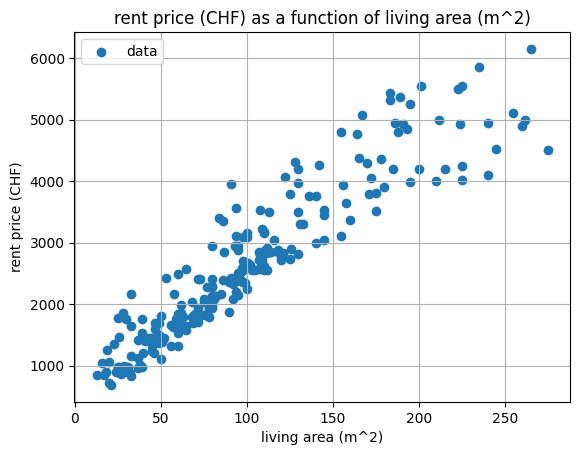

In [13]:
plot_data_prediction(living_area, rent_price, x_title="living area (m^2)", y_title="rent price (CHF)")

## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows:

\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x
\end{equation*}

We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by:

\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}

This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following :

\begin{equation*}
	\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}

intercept (theta_0): 657.6890591150313
slope (theta_1)    : 19.661179947454315


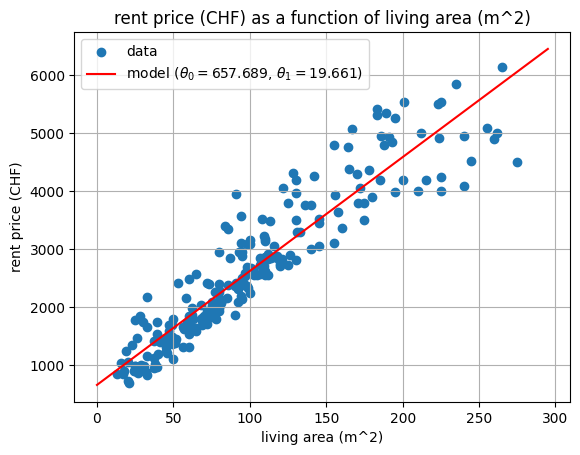

In [14]:
# see Eq. (3), (4) and (5) of the MPW2 pdf
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price
ne_theta = inv(X.T @ X) @ X.T @ y

print("intercept (theta_0):", ne_theta[0])  # should be around 658
print("slope (theta_1)    :", ne_theta[1])  # should be around 19.7

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = ne_theta[0] + ne_theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title="living area (m^2)",
    y_title="rent price (CHF)",
    theta_0=ne_theta[0],
    theta_1=ne_theta[1],
)

intercept (theta_0): -1.0408340855860843e-16
slope (theta_1)    : 0.9324195941786986


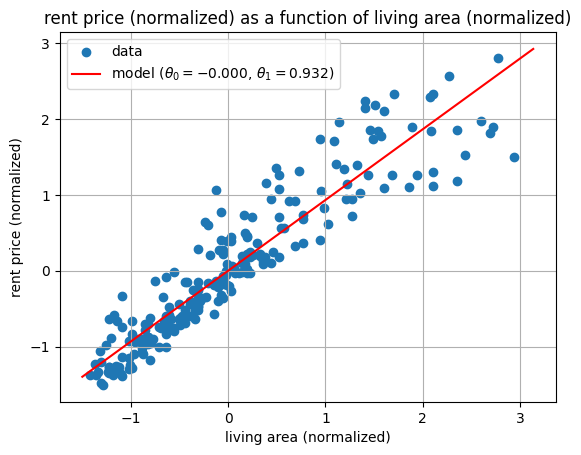

In [ ]:
# Plot Normalised Data
# see Eq. (3), (4) and (5) of the MPW2 pdf
X_norm = np.c_[np.ones(len(living_area_norm)), living_area_norm]
y_norm = rent_price_norm
ne_theta_norm = inv(X_norm.T @ X_norm) @ X_norm.T @ y_norm

print("intercept (theta_0):", ne_theta_norm[0])  # should be around 658
print("slope (theta_1)    :", ne_theta_norm[1])  # should be around 19.7

x_curve = np.array(np.linspace(-1.5, np.max(X_norm) + 0.2, 20))
y_curve = ne_theta_norm[0] + ne_theta_norm[1] * x_curve

plot_data_prediction(
    living_area_norm,
    rent_price_norm,
    x_curve,
    y_curve,
    x_title="living area (normalized)",
    y_title="rent price (normalized)",
    theta_0=ne_theta_norm[0],
    theta_1=ne_theta_norm[1],
)

The values of $\theta_0$ and $\theta_1$ obtained above are your references for the rest of the exercises.
Parameter $\theta_1$ defines the slope, equal to the augmentation of the rent price for each additional square meter of living area. Parameter $\theta_0$ defines the intercept, equal to the rent price when the living area is zero. We can observe a price evolution of around 20 CHF per additional square meter ($\theta_1 = 19.7$).

b) Compute the overall MSE loss :

In [16]:
def mse_loss(y_hat, y):
    N = len(y)
    return (1 / (2 * N)) * np.sum((y_hat - y) ** 2)


y_hat = ne_theta[0] + ne_theta[1] * living_area
J = mse_loss(y_hat, y)
print("The total value of the loss is", J)  # should be around 105K

The total value of the loss is 104915.13056913581


This value is minimum with the optimal $\theta$. It is pretty large because the data is noisy and the model is very simple (linear regression). Another frequently used metric is the root mean squared error (RMSE) which is the square root of the MSE. It is in the same unit as the target variable and is easier to interpret. Other commonly used metrics are the mean absolute error (MAE) and the mean absolute percentage error (MAPE). MAE is the average of the absolute  differences between the predicted values and the actual values. It is also in the same unit as the target variable and is less sensitive to outliers than the MSE. MAPE is the average of the absolute percentage differences between the predicted values and the actual values. It is a relative error metric that is useful when the target variable has a wide range of values.

In [17]:
def rmse_loss(y_hat, y):
    # Root Mean Squared Error: sqrt(1/N * sum((y_hat - y)^2))
    N = len(y)
    return np.sqrt((1 / N) * np.sum((y_hat - y) ** 2))


def mae_loss(y_hat, y):
    # Mean Absolute Error: 1/N * sum(|y_hat - y|)
    N = len(y)
    return (1 / N) * np.sum(np.abs(y_hat - y))


def mape_loss(y_hat, y):
    # Mean Absolute Percentage Error: 1/N * sum(|y_hat - y| / |y|)
    N = len(y)
    return (1 / N) * np.sum(np.abs((y_hat - y) / y))


rmse = rmse_loss(y_hat, y)
mae = mae_loss(y_hat, y)
mape = mape_loss(y_hat, y)
mape_percent = 100 * mape
print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{mape_percent:.1f}%")

The total value of the RMSE loss is 458
The total value of the MAE loss is 347
The total value of the MAPE loss is 14.6%


TO COMPLETE : 
- Implement the functions above to compute the MSE, RMSE, MAE and MAPE losses. Compute these losses for the linear regression model with the optimal $\theta$ obtained above.

Please see the code cell above.

-  Interpret the results.

The RMSE and MAE tell us how much the prediction differs from the true value on average. While the MAE is the average error, the RMSE is the square root of the average squared errors. The RMSE amplifies large errors if they exist. In this case, the RMSE is larger than the MAE. Therefore, we can conclude that there are some large outlier errors pulling RMSE up. This is also apparent in when plotting the data and the model's prediction line. As the living area and rent price increase, the data points are more spread out and therefore further from the prediction.

- Extra question: What could be the problem with MAPE?

MAPE is asymmetrically sensitive to low-value predictions. For example, a small absolute error on a cheap apartment contributes a much larger percentage than the same absolute error on an expensive one. This can give a distorted picture of overall model. quality

## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](images/linear-regression-graph.jpg)

Before creating the graph, you need to complete the Python code __cgnodes.py__ with a new operator node __MSELossNode(MetaNode)__ that computes the MSE loss between the predicted values and the actual values. The node should have two inputs: the predicted values and the actual values. The node should have one output: the MSE loss.

Then you can create the graph below.

In [18]:
# computational_graph/nodes/loss/mse.py
class MSENode(MetaNode):
    """Squared-error loss node: z = (y_true - y_pred)².

    Computes the squared difference between a prediction and a target.
    Gradient is propagated only to ``y_pred``; ``y_true`` is treated as a
    constant target with no learnable parameters.

    Attributes:
        _received_count (int): Number of parent values received in the current pass.
    """

    def __init__(self, y_pred: ValueNode, y_true: ValueNode, out_node: ValueNode, name: str = ""):
        """Create a squared-error node and wire up connections.

        Args:
            y_pred (ValueNode): Predicted value node (``parents[0]``).
            y_true (ValueNode): Target value node (``parents[1]``).
            out_node (ValueNode): Output node that receives ``(y_true - y_pred)²``.
            name (str): Optional human-readable identifier for this node.
        """
        super().__init__(name)
        y_pred.connect_to(self)
        y_true.connect_to(self)
        self.connect_to(out_node)
        self._received_count = 0

    def get_parent_values(self) -> tuple[float, float]:
        """Return the current values of both parent nodes.

        Returns:
            tuple[float, float]: ``(y_pred, y_true)`` in construction order.
        """
        return self.parents[0].v, self.parents[1].v

    def receive_parent_value(self, v: float):
        """Record that one parent has sent its value.

        The value itself is not stored here; it is read directly from
        ``parents[].v`` during ``forward`` and ``backward``.

        Args:
            v (float): Value forwarded by the calling parent (ignored locally).

        Raises:
            ValueError: If both inputs have already been received.
        """
        del v
        if self._received_count >= 2:
            raise ValueError("This node accepts 2 inputs that are already filled")
        self._received_count += 1
        if self._received_count == 2:
            self.input_ready = True

    def _reset_local(self):
        """Reset the received-input counter and readiness flag."""
        self._received_count = 0
        self.input_ready = False

    def forward(self):
        """Compute ``(y_true - y_pred)²`` and push it to children once both inputs are ready."""
        if self.input_ready:
            y_pred, y_true = self.get_parent_values()
            z = 0.5 * (y_true - y_pred) ** 2
            for node in self.children:
                node.receive_parent_value(z)
                node.forward()

    def backward(self, grad_z: float, batch_size: int = 1):
        """Propagate the gradient of the loss with respect to ``y_pred``.

        Uses ``d/dy_pred [(y_true - y_pred)²] = 2 * (y_pred - y_true)``,
        so the gradient passed upstream is ``2 * (y_pred - y_true) * grad_z``.

        Args:
            grad_z (float): Gradient of the loss with respect to this node's output.
            batch_size (int): Batch size to scale gradient
        """
        y_pred, y_true = self.get_parent_values()
        grad_x = (y_pred - y_true) * grad_z
        self.parents[0].backward(grad_x, batch_size)

    def __repr__(self) -> str:
        return f"MSENode(y_pred={self.parents[0].name}, y_true={self.parents[1].name}, out={self.children[0].name})"

In [19]:
# first create all ValueNode objects
theta_0 = ValueNode("theta_0", trainable=True)
theta_1 = ValueNode("theta_1", trainable=True)
x = ValueNode("x")
y = ValueNode("y")
q = ValueNode("q")
y_hat = ValueNode("y_hat")
j = ValueNode("j")

# then create all OperatorNode objects
mult = MultiplyNode(x, theta_1, q)
add = AddNode([theta_0, q], y_hat)
loss = MSENode(y_hat, y, j)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x, theta_0, theta_1, y], [j])

In [20]:
# try a forward pass with dummy values
cg.reset_values()
cg.forward([[0.0, 0.0, 0.0, 1.0]])
print(cg)

print(j.v)  # should give 0.5

 --- Input Nodes --- 
ValueNode(name=x, v=0.0, grad=None)
ValueNode(name=theta_0, v=0.0, grad=None)
ValueNode(name=theta_1, v=0.0, grad=None)
ValueNode(name=y, v=1.0, grad=None)

 --- Intermediate Notes --- 
MultiplyNode(in1=x, in2=theta_1, out=q)
ValueNode(name=q, v=0.0, grad=None)
AddNode(in1=theta_0, in2=q, out=y_hat)
ValueNode(name=y_hat, v=0.0, grad=None)
MSENode(y_pred=y_hat, y_true=y, out=j)

 --- Output Notes --- 
ValueNode(name=j, v=0.5, grad=None)

0.5


In [21]:
print(cg)
cg.backward()
print(theta_0.grad_v, theta_1.grad_v)  # should give -1.0 -0.0

 --- Input Nodes --- 
ValueNode(name=x, v=0.0, grad=None)
ValueNode(name=theta_0, v=0.0, grad=None)
ValueNode(name=theta_1, v=0.0, grad=None)
ValueNode(name=y, v=1.0, grad=None)

 --- Intermediate Notes --- 
MultiplyNode(in1=x, in2=theta_1, out=q)
ValueNode(name=q, v=0.0, grad=None)
AddNode(in1=theta_0, in2=q, out=y_hat)
ValueNode(name=y_hat, v=0.0, grad=None)
MSENode(y_pred=y_hat, y_true=y, out=j)

 --- Output Notes --- 
ValueNode(name=j, v=0.5, grad=None)

-1.0 -0.0


### 4.2 Plain vanilla stochastic gradient descent

In [22]:
def plot_training_log(
    plots: list[tuple[str, list[float]] | str],
    x: list[int],
    y: list[int],
    t0: float,
    t1: float,
    t2: float = 0.0,
    n_cols: int = 2,
    normalized: bool = False,
):
    n_rows = ceil(len(plots) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3.5 * n_rows))
    axes = axes.flatten()
    fig.suptitle("Training log")

    for ax, plot in zip(axes, plots):
        if plot == "scatter":
            ax.scatter(x, y, s=1.0)
            x_curve = np.linspace(np.min(x), np.max(x), 2)
            if normalized:
                y_ne_curve = ne_theta_norm[0] + ne_theta_norm[1] * x_curve
            else:
                y_ne_curve = ne_theta[0] + ne_theta[1] * x_curve
            y_curve = t0 + t1 * x_curve + t2 * x_curve**2
            ax.plot(x_curve, y_ne_curve, color="gray", linestyle="--")
            ax.plot(x_curve, y_curve, color="red")
            ax.set_title("points and model output")

        else:
            label, values = plot
            ax.plot(values)
            ax.set_title(label)

    for ax in axes[len(plots) :]:
        ax.set_visible(False)

    fig.tight_layout()

Complete the code below to implement the stochastic gradient descent algorithm for linear regression. Make sure you understand the code and the algorithm before completing it. We will bring incremental evolution to this code so make sure you understand each lines of it. The code is pretty straightforward, but you can ask for help if you have any questions. 

intercept (theta_0): 1.0047378737185038
slope (theta_1)    : 24.471551543552465
The total value of the loss is 163446.09520592692


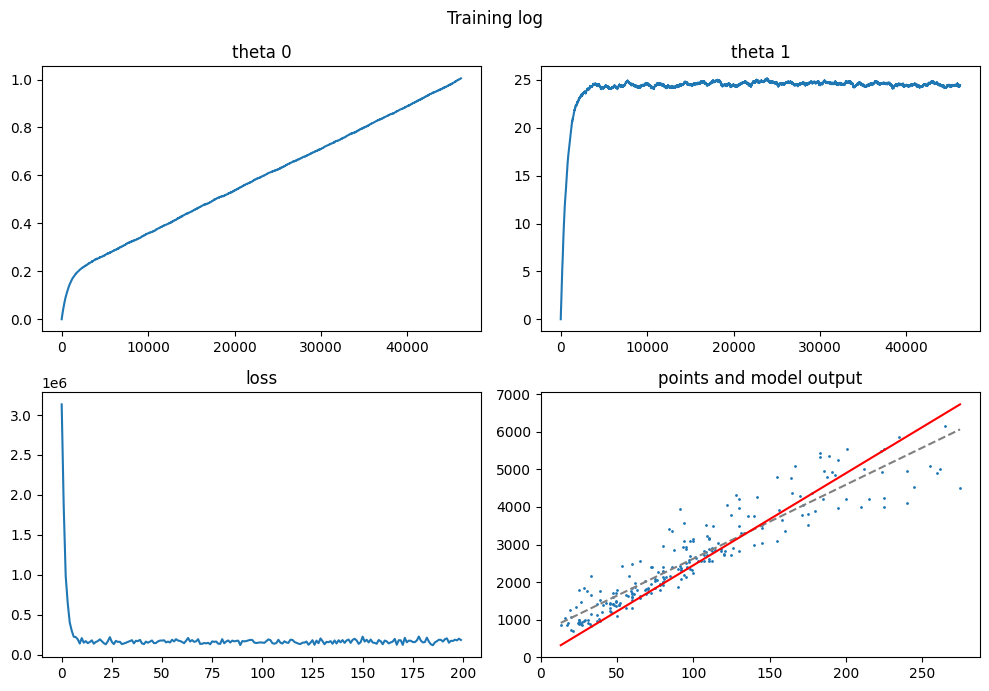

In [23]:
alpha = 0.0000001  # learning rate
epochs = 200  # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0  # initial value of theta_0
t1 = 0.0  # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []  # to log the evolution of theta_0
t1_evolution = []  # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set

        # We decided to split reset_values and zero_grad to make batching in
        # the optimizer easier
        cg.reset_values()
        cg.zero_grad()

        cg.forward([[living_area[n], t0, t1, rent_price[n]]])
        cg.backward()
        t0 = t0 - (alpha * theta_0.grad_v)  # update rule for theta_0
        t1 = t1 - (alpha * theta_1.grad_v)  # update rule for theta_1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
# Note that this calls the mse_loss function defined in section 3, not from MSELossNode()
print("The total value of the loss is", J)
plot_training_log(
    plots=[
        ("theta 0", t0_evolution),
        ("theta 1", t1_evolution),
        ("loss", loss_evolution),
        "scatter",
    ],
    x=living_area,
    y=rent_price,
    t0=t0,
    t1=t1,
)

#### Observations

Evolution of the loss: The loss is large in the early epochs and decreases sharply within the first 10 training steps. This is the desired effect because it indicates that the model is correcting itself early on. The model is possibly doing so by finding key patterns in the data such as the linear relationship between the living area and the rental price. After the initial drop, the loss stays low, fluctuating around 0.1 for the remainder of the epochs. This indicates that the model converges very early. The fluctuations in the loss in the plateau region could indicate that the learning rate is too high.

Evolution of theta1: Theta 1 is initialised at 0 and the parameter quickly finds its optimal value, evidenced by the sharp increase and continued fluctuation around 24. There are only minor fluctuations after the initial increase, indicating that the parameter is stable.

Evolution of theta0: Theta 0 increases gradually, almost linearly, from 0 to 1 over the training. In contrast to Theta 1, Theta 0 is still increasing at the end of the training. It never flattens out indicating that it has not converged. More training iterations or a larger learning rate might be needed for this parameter specifically.

### 4.3 Batched gradient descent

Modify the code from the above stochastic gradient descent to implement a batched gradient descent algorithm. The idea is to compute the gradients on a batch of samples instead of a single sample. This can help to smooth the evolution of the parameters and the loss, and can also speed up the convergence.

intercept (theta_0): 0.462303996033526
slope (theta_1)    : 24.601605754693583
The total value of the loss is 163569.23481383966


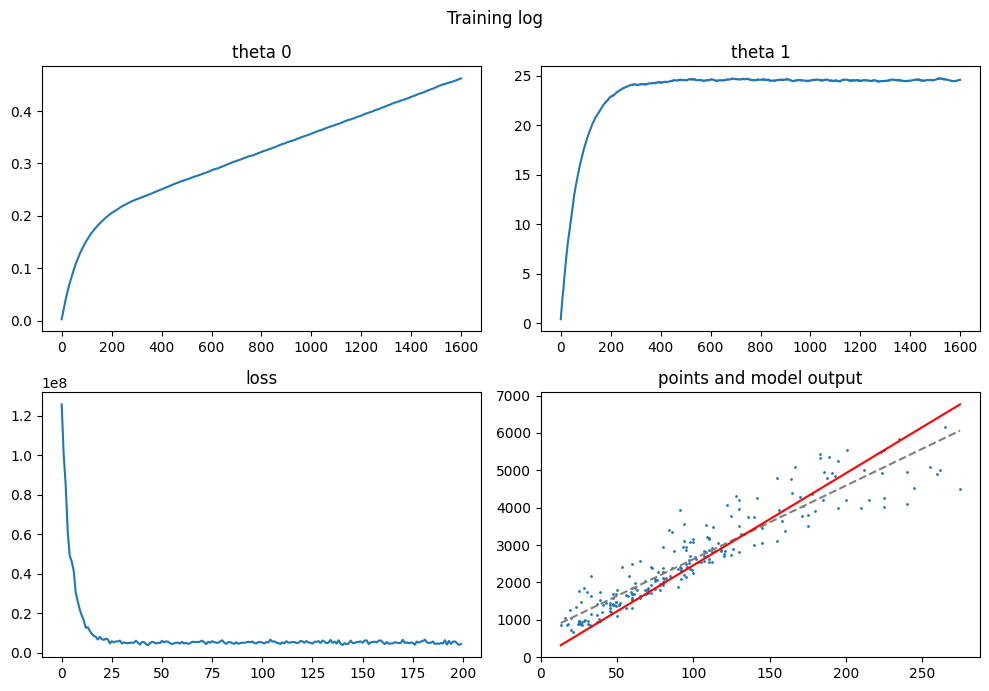

In [24]:
alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD
# as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        grad_t0_sum = 0.0  # accumulator for theta_0 gradients
        grad_t1_sum = 0.0  # accumulator for theta_1 gradients

        batch_indices = random.sample(range(N), batch_size)  # sample a batch

        for n in batch_indices:
            # We decided to split reset_values and zero_grad to make batching in
            # the optimizer easier
            cg.reset_values()
            cg.zero_grad()

            cg.forward([[living_area[n], t0, t1, rent_price[n]]])
            cg.backward()
            grad_t0_sum += theta_0.grad_v  # accumulate gradients for this batch
            grad_t1_sum += theta_1.grad_v
            epoch_loss += j.v

        # update theta with the average gradient over the batch
        t0 = t0 - alpha * (grad_t0_sum / batch_size)
        t1 = t1 - alpha * (grad_t1_sum / batch_size)
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(
    plots=[
        ("theta 0", t0_evolution),
        ("theta 1", t1_evolution),
        ("loss", loss_evolution),
        "scatter",
    ],
    x=living_area,
    y=rent_price,
    t0=t0,
    t1=t1,
)

#### Observations

- Evolution of theta_0 and theta_1: ...
- Do we still have the same observation as in the plain stochastic version regarding the convergence of theta_1 and the slow evolution of theta_0 ? ...

Evolution of theta_0 and comparison: Theta 0 has the same gradually increasing pattern as before and still hasn't converged by the end of training. In terms of actual gradient updates, theta 0 is converging even slower than in the plain stochastic version. Theta 0 reaches ~0.47 after 1600 training steps, whereas the previous run reached ~1.0 after 50,000 steps.

Evolution of theta_1 and comparison: Theta 1 converges quickly, reaching ~24–25 within the first ~300 epochs which is very similar behavior to the plain stochastic version. The plateau region after the initial sharp increase is slightly smoother than before, suggesting batch averaging helps stabilize this parameter once it's near its optimum.

- Can we use larger learning rates than in the plain stochastic version ? ...

In general, yes, because the gradient estimate is less noisy. In SGD, each update uses a single sample and the gradient can vary greatly from the true gradient direction. A large learning rate amplifies this noise, easily causing divergence. With a batch, gradients are averaged over multiple samples, giving a more reliable estimate of the true gradient direction. Additionally, because the batch gradient is smoother, a larger step in that direction is less likely to overshoot catastrophically. The averaging effect acts as a natural damper.


This case is a bit of a unique case as we have two parameters. The same observations can be made in both the stochastic and the batched experiments: Theta 1 converges readily while theta 0 lags far behind. Comparing the two experiments shows that this observation is actually amplified by batching. This behaviour is likely a feature scaling problem. The gradient with respect to theta 0 is much smaller in magnitude than that for theta 1, so the learning rate that works for theta 1 is too small for theta 0 to move meaningfully. Increasing the learning rate could help theta 0 converge but there is a risk of destabilising theta 1. The best fix is to use different learning rates for each parameter as seen in the experiment below.


## 5. Optimizers
### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

This is a very simple idea that can help to speed up the convergence of $\theta_0$ and $\theta_1$. We can use a larger learning rate for $\theta_1$ than for $\theta_0$ as $\theta_1$ converges faster than $\theta_0$. This idea is actually a first step towards RMSProp which is an optimizer that uses different learning rates for different parameters based on the history of the gradients.

intercept (theta_0): 481.9033654551579
slope (theta_1)    : 21.009547899654383
The total value of the loss is 109123.5362776908


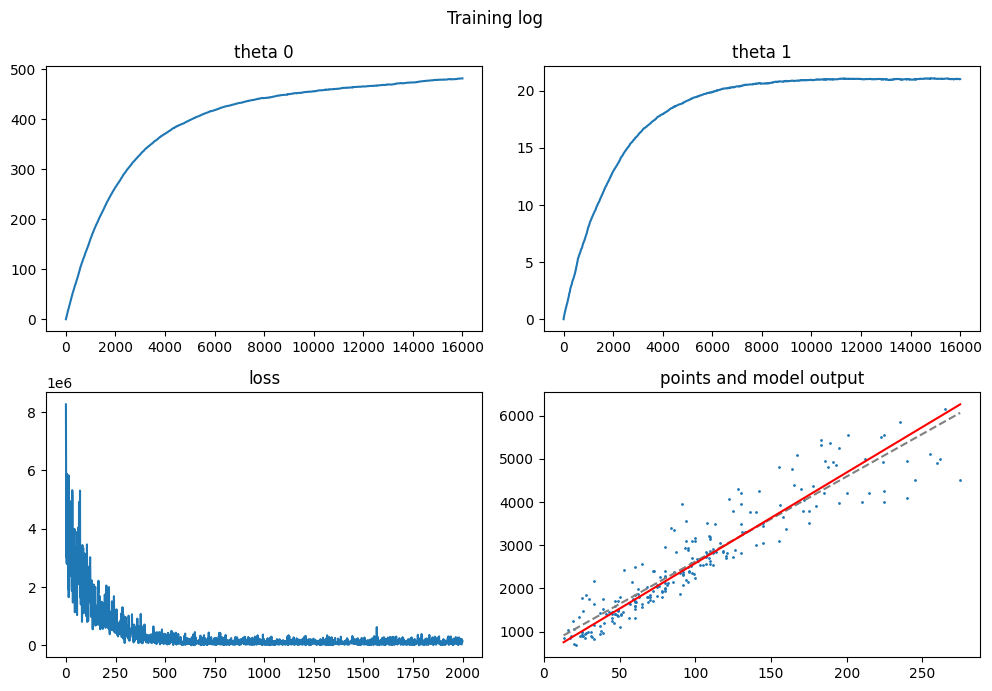

In [25]:
alpha_t0 = 0.0025  # learning rate for theta_0
alpha_t1 = 0.000001  # learning rate for theta_1
epochs = 2000  # number of epochs (an epoch is a loop over the whole training set)

batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        batch_indices = random.sample(range(N), batch_size)  # sample a batch

        # We decided to split reset_values and zero_grad to make batching in
        # the optimizer easier
        cg.reset_values()
        cg.zero_grad()

        cg.forward([[living_area[n], t0, t1, rent_price[n]] for n in batch_indices])
        cg.backward(32)
        epoch_loss += j.v

        # update theta with the average gradient over the batch
        t0 = t0 - alpha_t0 * theta_0.grad_v
        t1 = t1 - alpha_t1 * theta_1.grad_v
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(
    plots=[
        ("theta 0", t0_evolution),
        ("theta 1", t1_evolution),
        ("loss", loss_evolution),
        "scatter",
    ],
    x=living_area,
    y=rent_price,
    t0=t0,
    t1=t1,
)

#### Observations

Training was run for 2000 epochs (10x previous experiments). Both parameters converge more gradually than in earlier runs. Theta 0 (\~475) is nearly converged, while theta 1 (\~21) is still climing slowly. This is a direct consequence of the learning rates differing by a factor of 2500 (`alpha_t0 = 0.0025` vs `alpha_t1 = 0.000001`). The two thetas also differ in scale by over an order of magnitude, which reflects the underlying disparity in feature scale and further contributes to the uneven convergence. Additionally, this difference in scale is likely explains the convergece problems of theta 0 in the previous experiments.

The loss curve appears more erratic compared to previous experiments, likely due to the y-axis scale rather than instability in training. Since `cg.backward(32)` averages gradients over the batch, the effective learning rate is consistent across batch sizes.

The fitted line is visibly closer to the closed-form solution than in previous runs, confirming that the extended training combined with different learning rates for each parameter improved parameter estimates.

### 5.2 Idea 2: accelerate the movement of the parameters with the principle of momentum

The idea is to accelerate the modification of the parameters introducing a memory about the previous evolutions of the gradients. If the gradients are always in the same direction, we can accelerate the movement of the parameter updates in that direction. This is done by introducing a new variable called *momentum* that accumulates the gradients over time, and using this variable to update the parameters instead of the current gradient. The analogy would be to think of a ball rolling down the hill of parameter space, accelerating when the successive values of the gradients are aligned. The classical momentum equations are the following:

\begin{equation*}
	m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
    \theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

The value $\beta$ is multiplying the previous momentum and controls how much inertia we inject in the system. Values of $\beta$ above $1.0$ will make the system diverge and overflow. Too small $\beta$ value will not help if the way to the optimal value of the $\theta$ is far. A frequently used default is $\beta = 0.9$, but this is a value that needs to be tuned for each specific problem.

In our previous experiments, the parameter $\theta_0$ has gradients that seem to go always in the same direction. Convergence would benefit from this memory, accelerating the growth of $\theta_0$. This is less the case for $\theta_1$ which shows a quick convergence to a plateau, with gradients that are not always in the same direction. This is why we can expect a bigger improvement for $\theta_0$ than for $\theta_1$ with this idea. To handle this, we recommend to introduce two new variables `momentum_t0` and `momentum_t1` that accumulate the gradients of $\theta_0$ and $\theta_1$ respectively. We then use these momentum variables to update the parameters instead of the current gradients.

Complete the code below to implement the momentum optimizer for linear regression.

intercept (theta_0): 0.89392039829038
slope (theta_1)    : 24.618291346304197
The total value of the loss is 163515.75523991205


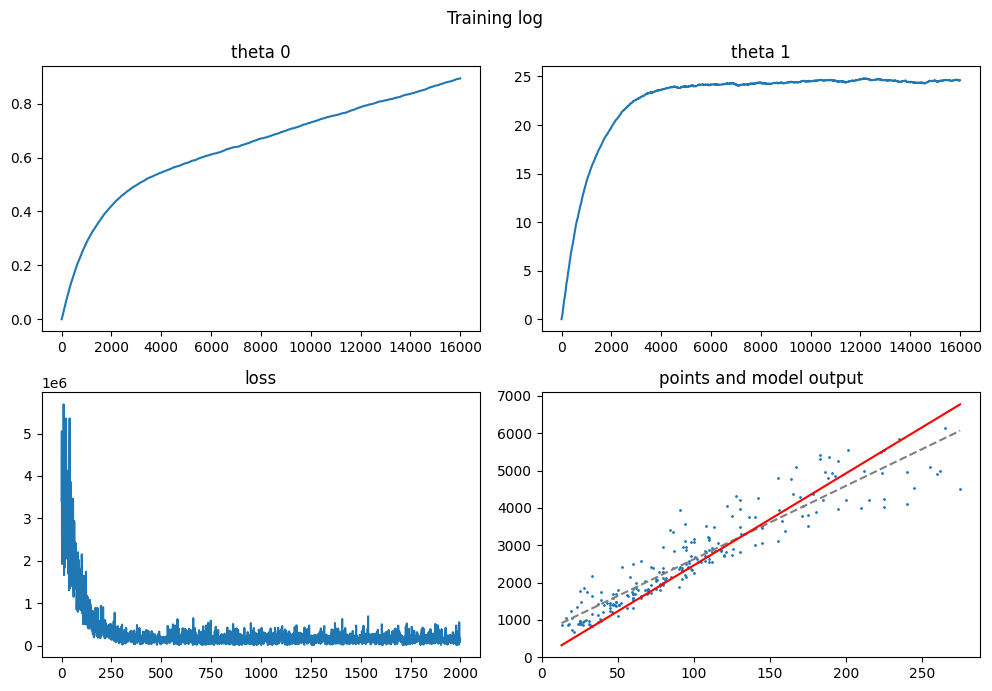

In [26]:
alpha = 0.000001
beta_momentum_t0 = 0.8
beta_momentum_t1 = 0.5
epochs = 2000

batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0
momentum_t0 = 0.0
momentum_t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1
    epoch_loss = 0.0
    for step in range(n_steps):
        cg.reset_values()
        cg.zero_grad()

        batch_indices = random.sample(range(N), batch_size)
        cg.forward([[living_area[n], t0, t1, rent_price[n]] for n in batch_indices])
        cg.backward(batch_size)
        epoch_loss += j.v

        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * theta_0.grad_v
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * theta_1.grad_v

        t0 = t0 - momentum_t0
        t1 = t1 - momentum_t1

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(
    plots=[
        ("theta 0", t0_evolution),
        ("theta 1", t1_evolution),
        ("loss", loss_evolution),
        "scatter",
    ],
    x=living_area,
    y=rent_price,
    t0=t0,
    t1=t1,
)

#### Observations

Theta 0 reaches ~0.9, far below the expected ~475 from previous experiments. A single shared `alpha = 0.000001` is too small for theta 0's gradient scale -- momentum amplifies updates in a consistent direction, but cannot compensate for an insufficient base learning rate. No amount of beta tuning resolves this, confirming that theta 0 requires its own learning rate. Its convergence curve sits between the experiment with a shared learning rate and the one with per-parameter rates.

Theta 1 converges smoothly and reaches a stable plateau, behaving as expected.

As a consequence of theta 0 failing to converge, the fitted line deviates noticeably from the closed-form solution, particularly at higher x values.

## 6. Optional objectives

Pick at least 2 of the following optional objectives to further explore and analyze the performance of your models:

- Investigate the use of 2nd order model instead of the simple linear model.
- Re-implement and experiment with more advanced optimizers such as RMSProp, Nesterov or Adam.
- Implement an early stopping strategy in your training loop.
- Implement a *Learning Rate Decay on Plateau* strategy in the training loop.
- Normalize the input data with a zero norm approach and compare to your experiments without normalization.


### Normalized input data

Input features with very different scales cause the gradient descent to progress slowly, because the learning rate must be small enough for the largest feature. Normalizing each feature to zero mean and unit variance puts all inputs on the same scale, which allows a much larger learning rate and faster convergence. We re-run the batched SGD from section 4 on the normalized living area and rent price and compare the resulting theta values and loss to the unnormalized case.

intercept (theta_0): -0.006709608049080629
slope (theta_1)    : 0.935917742755442
The total value of the loss is 0.0653254781376344


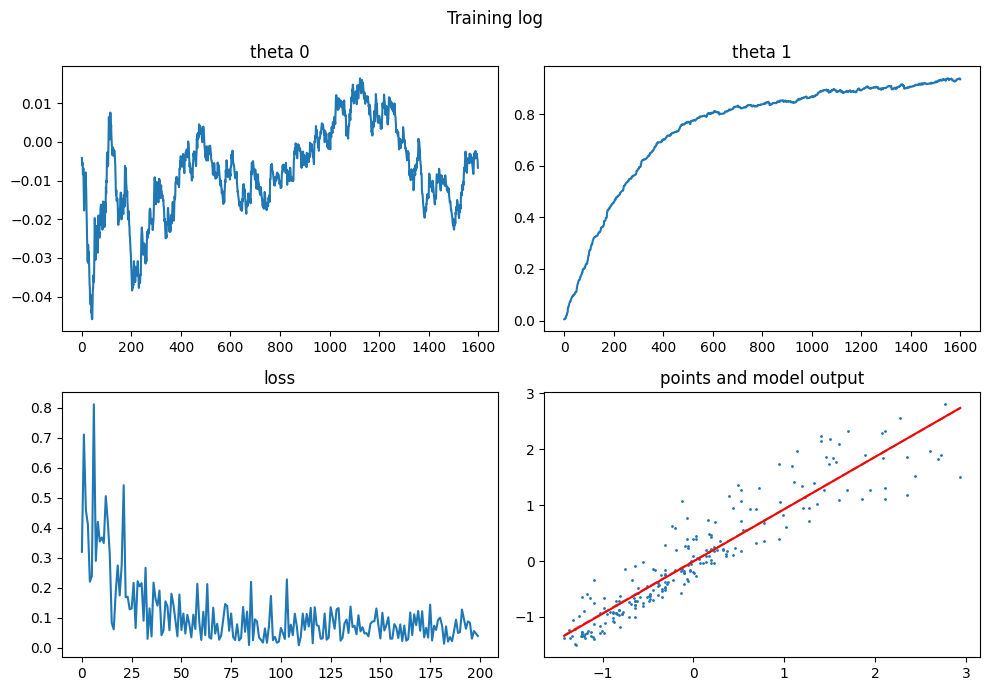

In [27]:
alpha = 0.1
epochs = 200
batch_size = 32
N = len(living_area_norm)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        batch_indices = random.sample(range(N), batch_size)  # sample a batch

        cg.reset_values()
        cg.zero_grad()

        cg.forward([[living_area_norm[n], t0, t1, rent_price_norm[n]] for n in batch_indices])
        cg.backward(batch_size)

        epoch_loss += j.v

        # update theta with the average gradient over the batch
        t0 = t0 - alpha * theta_0.grad_v
        t1 = t1 - alpha * theta_1.grad_v
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area_norm
J = mse_loss(y_hat, rent_price_norm)
print("The total value of the loss is", J)
plot_training_log(
    plots=[
        ("theta 0", t0_evolution),
        ("theta 1", t1_evolution),
        ("loss", loss_evolution),
        "scatter",
    ],
    x=living_area_norm,
    y=rent_price_norm,
    t0=t0,
    t1=t1,
    normalized=True,
)

#### Observations

Both parameters now train with a single shared learning rate (`alpha = 0.1`), which previously always failed for one of the two thetas. Normalization equalizes the gradient scales of theta 0 and theta 1, making a shared learning rate sufficient.

Theta 0 oscillates around ~0 with an amplitude of ~0.04, which is expected, as the intercept of a zero-mean dataset should be near zero. The oscillation indicates `alpha = 0.1` is slightly large for theta 0, but the amplitude is small enough to not meaningfully affect the fit. Theta 1 converges quickly to a stable plateau.

The scatter plot confirms normalization was applied correctly to both features and targets, with data centered around 0. The fitted line closely matches the closed-form solution.

The loss is in normalized units (MSE on z-scores) and is therefore not directly comparable to previous experiments. Training converged in only 200 epochs, compared to 2000 in previous runs, demonstrating that normalization significantly speeds up convergence.

### 2nd order model

The linear model assumes rent price grows proportionally with area, but the relationship may curve. A second-order (quadratic) model adds a term $\theta_2 x^2$, giving the predictor $\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2$. We extend the computational graph with a SquareNode and an extra MultiplyNode for $\theta_2 x^2$, then train on normalized data to check whether the extra parameter improves the fit.

In [28]:
# this function plots the evolution of the loss and the parameters during training, as well
# as the data points and the model curve at the end of training. The last value of the
# evolution of theta_0 and theta_1 is used to plot the model curve.
def plot_training_log_2nd_order(loss_evolution, t0_evolution, t1_evolution, t2_evolution, x, y):
    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(10, 7))
    fig.suptitle("Training log")
    ax1.plot(t0_evolution)
    ax1.set_title("theta 0")
    ax2.plot(t1_evolution)
    ax2.set_title("theta 1")
    ax3.plot(t2_evolution)
    ax3.set_title("theta 2")
    ax4.plot(loss_evolution)
    ax4.set_title("loss")
    ax5.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = (
        t0_evolution[-1] + t1_evolution[-1] * x_curve + t2_evolution[-1] * x_curve**2
    )  # use last value of evolution as thetas
    ax5.plot(x_curve, y_curve, color="red")
    ax5.set_title("points and model output")
    fig.tight_layout()

In [29]:
# first create all ValueNode objects
cg2_theta_0 = ValueNode("theta_0", trainable=True)
cg2_theta_1 = ValueNode("theta_1", trainable=True)
cg2_theta_2 = ValueNode("theta_2", trainable=True)
cg2_x = ValueNode("x")
cg2_y = ValueNode("y")

# intermediate nodes
cg2_q1 = ValueNode("q1")
cg2_q2 = ValueNode("q2")
cg2_x2 = ValueNode("x2")
cg2_y_hat = ValueNode("y_hat")
cg2_j = ValueNode("j")

# then create all OperatorNode objects
cg2_mult1 = MultiplyNode(cg2_x, cg2_theta_1, cg2_q1)
cg2_square = SquareNode(cg2_x, cg2_x2)
cg2_mult2 = MultiplyNode(cg2_x2, cg2_theta_2, cg2_q2)
cg2_add = AddNode([cg2_theta_0, cg2_q1, cg2_q2], cg2_y_hat)
cg2_loss = MSENode(cg2_y_hat, cg2_y, cg2_j)

# finally, build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg2 = CompGraph([cg2_x, cg2_theta_0, cg2_theta_1, cg2_theta_2, cg2_y], [cg2_j])
print(cg2)

 --- Input Nodes --- 
ValueNode(name=x, v=None, grad=None)
ValueNode(name=theta_0, v=None, grad=None)
ValueNode(name=theta_1, v=None, grad=None)
ValueNode(name=theta_2, v=None, grad=None)
ValueNode(name=y, v=None, grad=None)

 --- Intermediate Notes --- 
MultiplyNode(in1=x, in2=theta_1, out=q1)
ValueNode(name=q1, v=None, grad=None)
AddNode(in1=theta_0, in2=q1, in3=q2, out=y_hat)
ValueNode(name=y_hat, v=None, grad=None)
MSENode(y_pred=y_hat, y_true=y, out=j)
SquareNode(in=x, out=x2)
ValueNode(name=x2, v=None, grad=None)
MultiplyNode(in1=x2, in2=theta_2, out=q2)
ValueNode(name=q2, v=None, grad=None)

 --- Output Notes --- 
ValueNode(name=j, v=None, grad=None)



intercept (theta_0): 0.09327763048522722
slope (theta_1)    : 1.0107829277152525
exponent (theta_2) : -0.09995384578950245
The total value of the loss is 0.058630785250385946
 --- Input Nodes --- 
ValueNode(name=x, v=1.888119092165973, grad=-0.005175347237677047)
ValueNode(name=theta_0, v=0.09244361119805872, grad=-0.008340192871685019)
ValueNode(name=theta_1, v=1.009208199975915, grad=-0.015747277393375038)
ValueNode(name=theta_2, v=-0.10292711929910896, grad=-0.029732735096065024)
ValueNode(name=y, v=1.897900520938169, grad=None)

 --- Intermediate Notes --- 
MultiplyNode(in1=x, in2=theta_1, out=q1)
ValueNode(name=q1, v=1.9055052703449804, grad=-0.008340192871685019)
AddNode(in1=theta_0, in2=q1, in3=q2, out=y_hat)
ValueNode(name=y_hat, v=1.6310143490442484, grad=-0.008340192871685019)
MSENode(y_pred=y_hat, y_true=y, out=j)
SquareNode(in=x, out=x2)
ValueNode(name=x2, v=3.564993706201658, grad=0.0008584320266815021)
MultiplyNode(in1=x2, in2=theta_2, out=q2)
ValueNode(name=q2, v=-0.3669

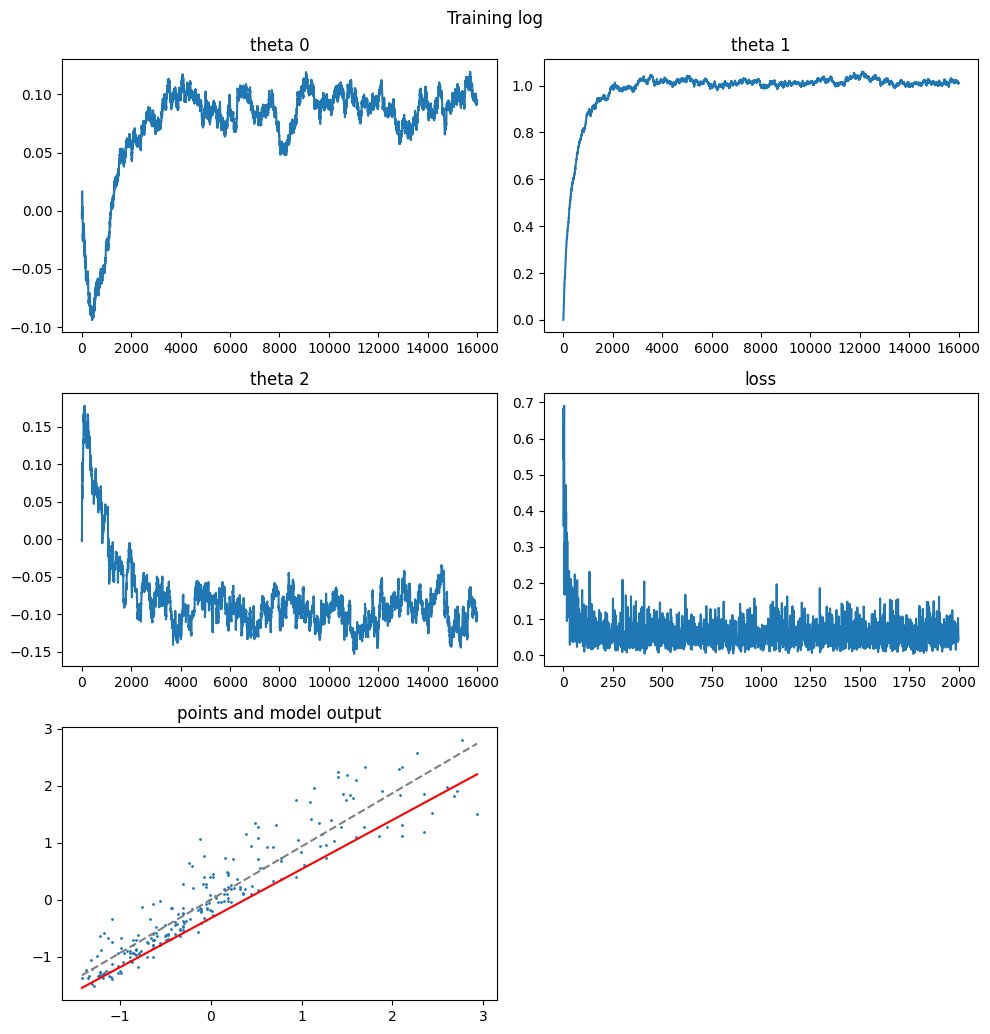

In [30]:
alpha = 1e-1
epochs = 2000
batch_size = 32
N = len(living_area_norm)

t0 = 0.0
t1 = 0.0
t2 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []
t2_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        batch_indices = random.sample(range(N), batch_size)

        cg2.reset_values()
        cg2.zero_grad()

        cg2.forward([[living_area_norm[n], t0, t1, t2, rent_price_norm[n]] for n in batch_indices])
        cg2.backward(batch_size)
        epoch_loss += cg2_j.v

        t0 = t0 - alpha * cg2_theta_0.grad_v
        t1 = t1 - alpha * cg2_theta_1.grad_v
        t2 = t2 - alpha * cg2_theta_2.grad_v

        t0_evolution.append(t0)
        t1_evolution.append(t1)
        t2_evolution.append(t2)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
print("exponent (theta_2) :", t2)
y_hat = t0 + t1 * living_area_norm + t2 * living_area_norm**2
J = mse_loss(y_hat, rent_price_norm)
print("The total value of the loss is", J)

print(cg2)
plot_training_log(
    plots=[
        ("theta 0", t0_evolution),
        ("theta 1", t1_evolution),
        ("theta 2", t2_evolution),
        ("loss", loss_evolution),
        "scatter",
    ],
    x=living_area_norm,
    y=rent_price_norm,
    t0=t0,
    t1=t1,
    t2=t2,
    normalized=True,
)

#### Observations

Training required extensive tuning and only converged with normalized data. Despite this, `alpha = 0.1`, the same learning rate as the previous linear normalized experiment, was sufficient, confirming that normalization is doing the heavy lifting rather than any special tuning for the quadratic model.

Theta 0 dips to ~-0.1 early in training before recovering to ~0.1, indicating an overshoot caused by the high learning rate. It continues to oscillate and does not fully converge. Theta 1 converges quickly and stabilizes around ~1.0, consistent with previous normalized experiments. Theta 2 settles around ~-0.08 with persistent oscillation, close to but not exactly zero, and never fully converging. The near-zero value of theta 2 suggests the relationship between living area and rent is approximately linear, and the quadratic term does not meaningfully improve the model.

The loss curve shows some notable spikes, consistent with occasional large gradient steps destabilizing training at a high learning rate even after apparent convergence.

The fitted line sits slightly below the closed-form solution, likely a consequence of theta 0 and theta 2 failing to fully converge. Since theta 2 = ~0, the model is effectively still linear, and the deviation from the closed-form is small.

### Advanced optimizers

Plain SGD uses a fixed learning rate for every parameter at every step, which can be slow or unstable. More advanced optimizers adapt the effective step size per parameter using gradient history. We implement three: GradientDescent with momentum (accumulates a velocity to accelerate consistent directions), RMSProp (scales the learning rate by the root of a moving average of squared gradients), and Adam (combines momentum and RMSProp with bias correction).

In [31]:
class AbstractOptimizer(ABC):
    def __init__(self, comp_graph: CompGraph, learning_rate: float):
        """
        Initializes the class with a computational graph and learning rate.

        Args:
            comp_graph: Computational graph to be used for executing operations
                or optimizations.
            learning_rate: Learning rate value to be used in optimization processes.
        """
        self.comp_graph = comp_graph
        self.learning_rate = learning_rate

    @abstractmethod
    def step(self):
        raise NotImplementedError

In [32]:
class GradientDescent(AbstractOptimizer):
    def __init__(self, comp_graph: CompGraph, learning_rate: float, momentum: float = 0.0):
        super().__init__(comp_graph, learning_rate)
        self.momentum = momentum
        self.velocity = {}

    def step(self):
        """
        Updates the values of trainable `MetaNodes` based.

        The `step` method performs a depth-first traversal of the computational graph, starting
        from the input nodes. It modifies nodes of the type `ValueNode` that are trainable by
        adjusting their value using the gradient of the node and the specified learning rate. To
        prevent duplicate visits, a set of visited nodes is maintained.
        """
        visited = set()

        def visit(node: MetaNode):
            if not isinstance(node, ValueNode) or not node.trainable or id(node) in visited:
                return
            visited.add(id(node))

            self.velocity[node] = self.momentum * self.velocity.get(node, 0.0) + node.grad_v
            node.v -= self.learning_rate * self.velocity[node]

            for child in node.children:
                visit(child)

        for in_node in self.comp_graph.in_nodes:
            visit(in_node)

        self.comp_graph.zero_grad()

In [33]:
class Adam(AbstractOptimizer):
    def __init__(
        self, comp_graph: CompGraph, learning_rate: float, beta1: float = 0.9, beta2: float = 0.9, eps: float = 1e-8
    ):
        super().__init__(comp_graph, learning_rate)
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.first_moment = {}
        self.second_moment = {}
        self.passes = 1

    def step(self):
        visited = set()

        def visit(node: MetaNode):
            if not isinstance(node, ValueNode) or not node.trainable or id(node) in visited:
                return
            visited.add(id(node))

            self.first_moment[node] = self.beta1 * self.first_moment.get(node, 0.0) + (1 - self.beta1) * node.grad_v
            self.second_moment[node] = (
                self.beta2 * self.second_moment.get(node, 0.0) + (1 - self.beta2) * node.grad_v**2
            )
            scaled_first_moment = self.first_moment[node] / (1 - self.beta1**self.passes)
            scaled_second_moment = self.second_moment[node] / (1 - self.beta2**self.passes)

            node.v -= self.learning_rate * scaled_first_moment / (sqrt(scaled_second_moment) + self.eps)

            for child in node.children:
                visit(child)

        for in_node in self.comp_graph.in_nodes:
            visit(in_node)

        self.comp_graph.zero_grad()
        self.passes += 1

In [34]:
class RMSProp(AbstractOptimizer):
    def __init__(self, comp_graph: CompGraph, learning_rate: float, decay: float = 0.9, eps: float = 1e-8):
        super().__init__(comp_graph, learning_rate)
        self.decay = decay
        self.eps = eps
        self.velocity = {}

    def step(self):
        """
        Performs one optimization step by visiting and updating trainable nodes in a computational graph.

        The optimizer traverses the computational graph starting from its input nodes and applies the optimization
        logic to all trainable nodes. It uses momentum-based gradient descent to update the parameter values.
        """
        visited = set()

        def visit(node: MetaNode):
            if not isinstance(node, ValueNode) or not node.trainable or id(node) in visited:
                return
            visited.add(id(node))

            self.velocity[node] = self.decay * self.velocity.get(node, 0.0) + (1 - self.decay) * node.grad_v**2
            node.v -= (self.learning_rate / sqrt(self.velocity[node] + self.eps)) * node.grad_v

            for child in node.children:
                visit(child)

        for in_node in self.comp_graph.in_nodes:
            visit(in_node)

        self.comp_graph.zero_grad()

intercept (theta_0): -0.03624447024857329
slope (theta_1)    : 0.8941450891831101
The total value of the loss is 0.06668614987394425


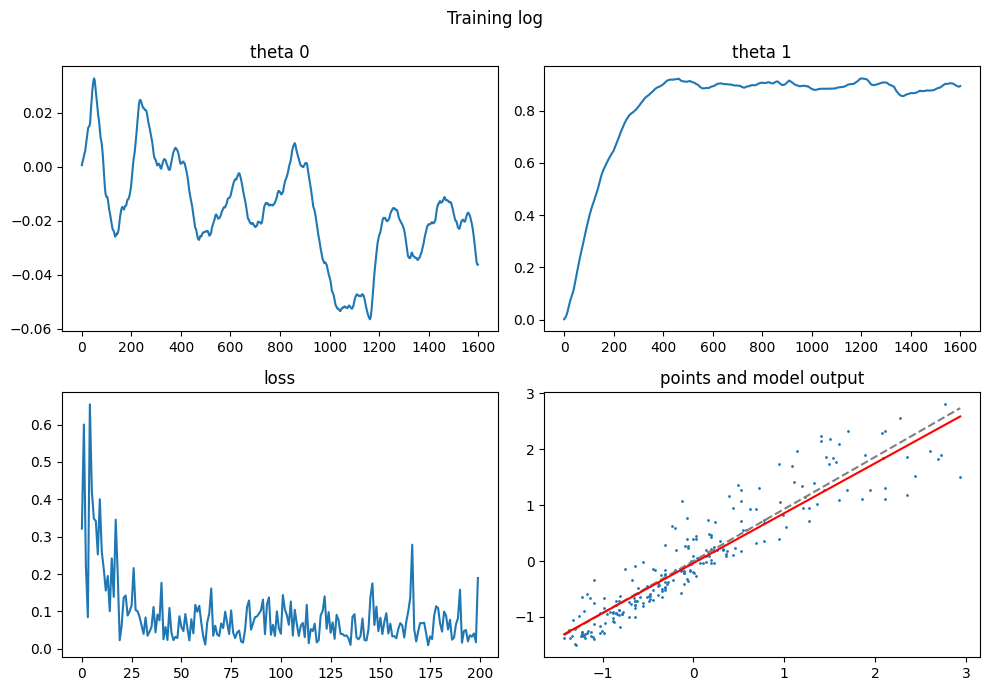

In [45]:
alpha = 0.01
epochs = 200
batch_size = 32
N = len(living_area_norm)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

optimizer = GradientDescent(comp_graph=cg, learning_rate=alpha, momentum=0.95)

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        batch_indices = random.sample(range(N), batch_size)  # sample a batch

        cg.forward([[living_area_norm[n], t0, t1, rent_price_norm[n]] for n in batch_indices])
        cg.backward(32)

        optimizer.step()

        epoch_loss += j.v
        t0 = theta_0.v
        t1 = theta_1.v

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area_norm
J = mse_loss(y_hat, rent_price_norm)
print("The total value of the loss is", J)
plot_training_log(
    plots=[
        ("theta 0", t0_evolution),
        ("theta 1", t1_evolution),
        ("loss", loss_evolution),
        "scatter",
    ],
    x=living_area_norm,
    y=rent_price_norm,
    t0=t0,
    t1=t1,
    normalized=True,
)

intercept (theta_0): -0.058274617769014554
slope (theta_1)    : 0.9472450104747201
The total value of the loss is 0.0671047122180533


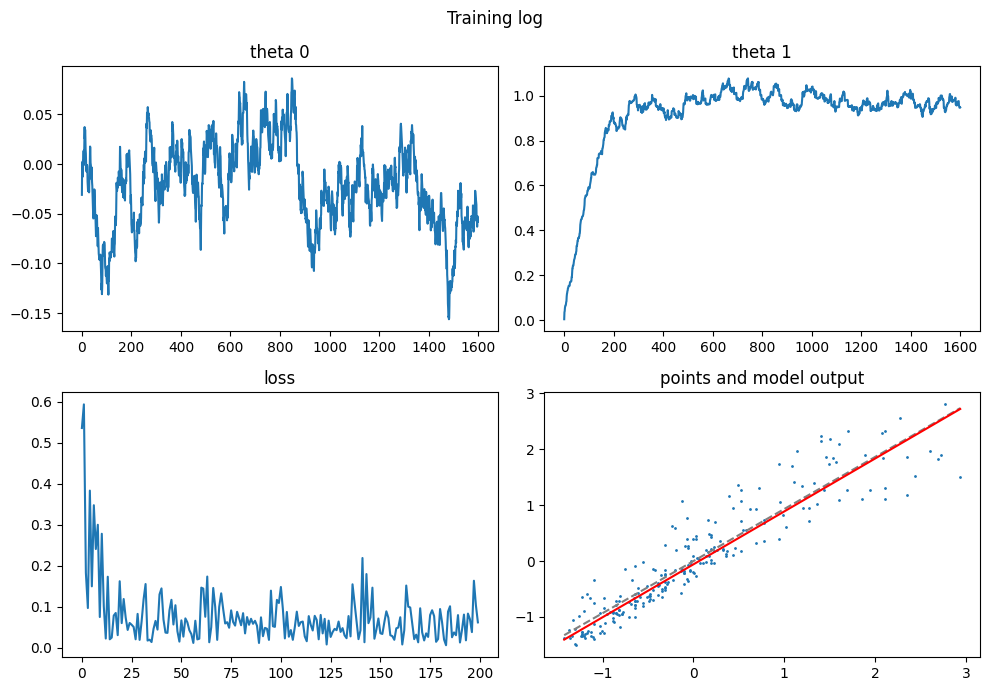

In [36]:
alpha = 0.01
epochs = 200
batch_size = 32
N = len(living_area_norm)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

optimizer = RMSProp(comp_graph=cg, learning_rate=alpha, decay=0.9)

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        batch_indices = random.sample(range(N), batch_size)  # sample a batch

        cg.forward([[living_area_norm[n], t0, t1, rent_price_norm[n]] for n in batch_indices])
        cg.backward(32)

        optimizer.step()

        epoch_loss += j.v
        t0 = theta_0.v
        t1 = theta_1.v

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area_norm
J = mse_loss(y_hat, rent_price_norm)
print("The total value of the loss is", J)
plot_training_log(
    plots=[
        ("theta 0", t0_evolution),
        ("theta 1", t1_evolution),
        ("loss", loss_evolution),
        "scatter",
    ],
    x=living_area_norm,
    y=rent_price_norm,
    t0=t0,
    t1=t1,
    normalized=True,
)

intercept (theta_0): -0.040118798775758295
slope (theta_1)    : 0.9593789482297335
The total value of the loss is 0.06646501258884518


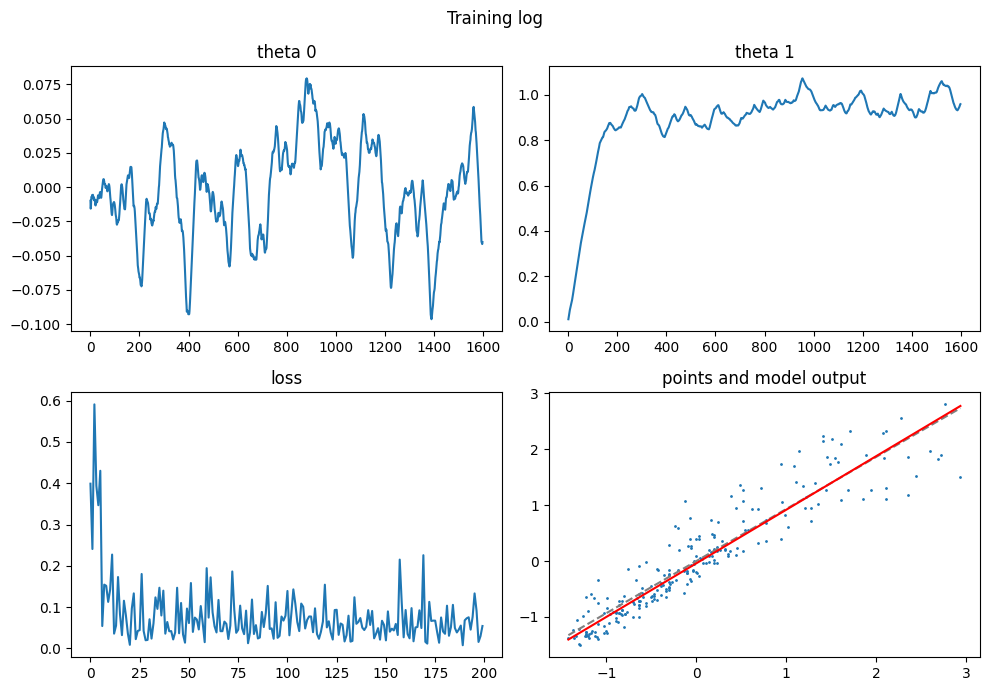

In [37]:
alpha = 0.01
epochs = 200
batch_size = 32
N = len(living_area_norm)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

optimizer = Adam(comp_graph=cg, learning_rate=alpha, beta1=0.9, beta2=0.9)

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        batch_indices = random.sample(range(N), batch_size)  # sample a batch

        cg.forward([[living_area_norm[n], t0, t1, rent_price_norm[n]] for n in batch_indices])
        cg.backward(32)

        optimizer.step()

        epoch_loss += j.v
        t0 = theta_0.v
        t1 = theta_1.v

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area_norm
J = mse_loss(y_hat, rent_price_norm)
print("The total value of the loss is", J)
plot_training_log(
    plots=[
        ("theta 0", t0_evolution),
        ("theta 1", t1_evolution),
        ("loss", loss_evolution),
        "scatter",
    ],
    x=living_area_norm,
    y=rent_price_norm,
    t0=t0,
    t1=t1,
    normalized=True,
)

#### Observations

All three optimizers were run on normalized data with a shared `alpha = 0.01` for 200 epochs, allowing a fair comparison of optimizer behavior without interference from gradient scale differences.

Across all three, theta 1 converges quickly and stabilizes around ~1.0, consistent with previous normalized experiments. Theta 0 oscillates around ~0 in all cases, which is expected for a zero-mean normalized dataset. The key differences are in the stability of theta 0 and the quality of the fitted line.

**Momentum** shows the largest oscillation amplitude in theta 0 (~0.06), and the fitted line sits noticeably below the closed-form solution. The high momentum value of 0.95 causes the velocity to accumulate across steps, overshooting the optimum for theta 0 repeatedly. Loss converges but remains noisy with occasional spikes.

**RMSProp** produces a slightly larger theta 0 oscillation amplitude (~0.15) than momentum, but the fitted line is much closer to the closed-form solution. The per-parameter learning rate scaling compensates for the gradient scale difference between theta 0 and theta 1 more effectively.

**Adam** behaves similarly to RMSProp, as expected given `beta2=0.9` makes the second moment estimate noisier and closer to RMSProp's behaviour. The fitted line closely matches the closed-form solution. Using the canonical `beta2=0.999` would likely differentiate the two more clearly.


### Early Stopping

Training too long wastes compute and can cause the model to overfit: the training loss keeps decreasing while generalization degrades. Early stopping monitors the loss after each epoch and halts training when the loss has not improved for a given number of epochs (the patience). This acts as a regularizer without changing the model or the optimizer. We apply it on top of Adam and observe at which epoch training is terminated.

Triggered early stopping at epoch 28. Current epoch loss (0.17217482132256864) is larger than the maximum of the last 20 epoch(s)
intercept (theta_0): -0.028116262423739227
slope (theta_1)    : 0.9445195525333357
The total value of the loss is 3866045.1840386502


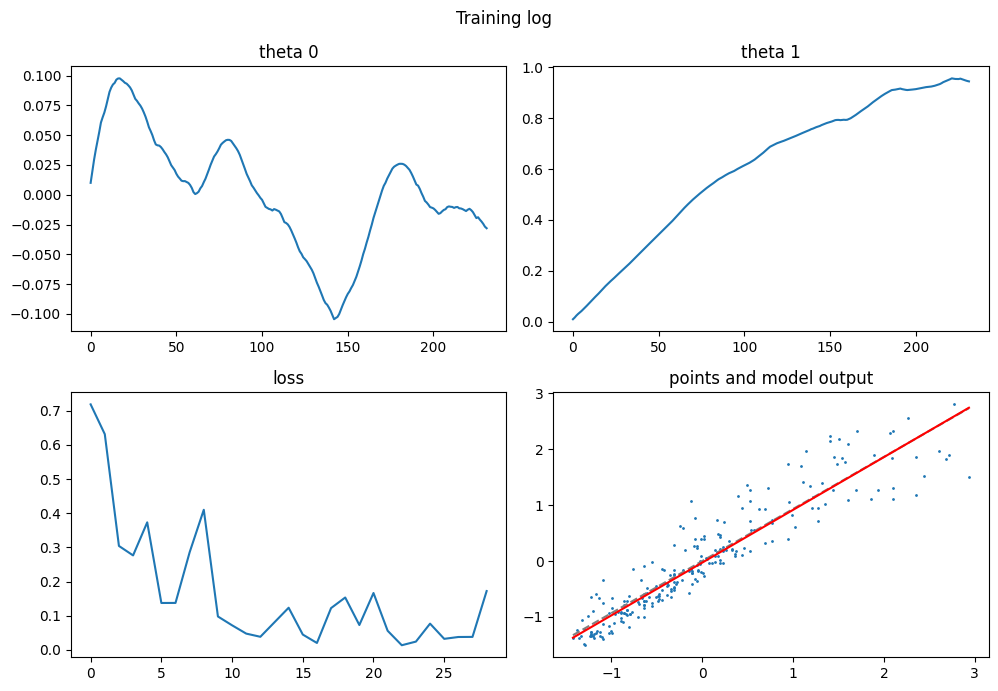

In [62]:
alpha = 1e-2
epochs = 200
batch_size = 32
N = len(living_area_norm)
t0 = 0.0
t1 = 0.0
patience = 20

loss_evolution = []
t0_evolution = []
t1_evolution = []

optimizer = Adam(comp_graph=cg, learning_rate=alpha, beta1=0.9, beta2=0.9)

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        batch_indices = random.sample(range(N), batch_size)  # sample a batch

        cg.forward([[living_area_norm[n], t0, t1, rent_price_norm[n]] for n in batch_indices])
        cg.backward(32)

        optimizer.step()

        epoch_loss += j.v
        t0 = theta_0.v
        t1 = theta_1.v

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    epoch_loss /= n_steps
    loss_evolution.append(epoch_loss)

    if epoch > patience and epoch_loss > sum(loss_evolution[-patience:-1]) / patience:
        print(
            f"Triggered early stopping at epoch {epoch}. Current epoch loss ({epoch_loss})"
            f" is larger than the maximum of the last {patience} epoch(s)"
        )
        break

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(
    plots=[
        ("theta 0", t0_evolution),
        ("theta 1", t1_evolution),
        ("loss", loss_evolution),
        "scatter",
    ],
    x=living_area_norm,
    y=rent_price_norm,
    t0=t0,
    t1=t1,
    normalized=True,
)

#### Observations

Training stopped at epoch 28, triggered by the mean-based early stopping criterion: the current epoch loss (0.172) exceeded the mean of the previous 20 epochs.

Theta 1 reaches ~0.94 at stopping, still visibly climbing and not fully converged. Theta 0 oscillates throughout with increasing amplitude toward the end. The fitted line is close to the closed-form solution but sits slightly below it, consistent with theta 1 not having fully converged. The loss shows a genuine uptick at epoch 28, confirming the stopping criterion fired on a real increase rather than noise.

### Reduce Learning Rate On Plateau

A large learning rate speeds up early training but can cause oscillations near the optimum. Learning rate decay on plateau reduces the learning rate by a fixed factor whenever the loss stops improving for several consecutive epochs. This lets the optimizer take large steps early on and fine-tune with smaller steps later. We implement a simple scheduler that checks the smoothed loss every few epochs and scales alpha down when progress stalls.

intercept (theta_0): 0.0007809532076676479
slope (theta_1)    : 0.9066741738640957
The total value of the loss is 0.06562856847335982


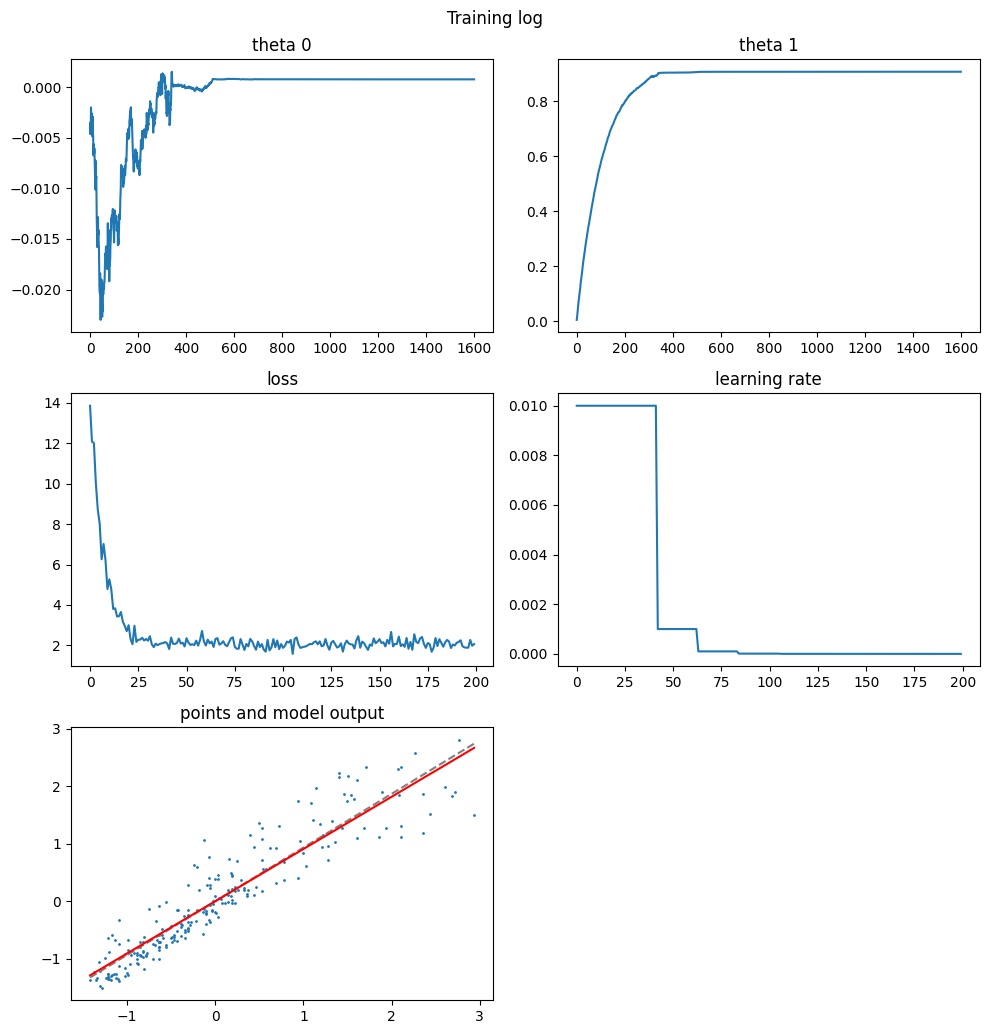

In [63]:
alpha = 1e-2
epochs = 200
batch_size = 32
N = len(living_area_norm)
t0 = 0.0
t1 = 0.0

scheduler_patience = 20
scheduler_factor = 0.1
last_decrease = 0
min_delta = 1e-10

loss_evolution = []
t0_evolution = []
t1_evolution = []
alpha_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1
    epoch_loss = 0.0
    for step in range(n_steps):
        grad_t0_sum = 0.0
        grad_t1_sum = 0.0

        batch_indices = random.sample(range(N), batch_size)  # sample a batch

        for n in batch_indices:
            cg.reset_values()
            cg.zero_grad()

            cg.forward([[living_area_norm[n], t0, t1, rent_price_norm[n]]])
            cg.backward()
            grad_t0_sum += theta_0.grad_v
            grad_t1_sum += theta_1.grad_v
            epoch_loss += j.v

        # update theta with the average gradient over the batch
        t0 = t0 - alpha * (grad_t0_sum / batch_size)
        t1 = t1 - alpha * (grad_t1_sum / batch_size)
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    epoch_loss /= n_steps

    smoothed = sum(loss_evolution[-scheduler_patience:]) / patience
    if epoch - last_decrease > scheduler_patience and epoch_loss > smoothed - min_delta:
        alpha *= 0.1
        last_decrease = epoch

    loss_evolution.append(epoch_loss)
    alpha_evolution.append(alpha)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area_norm
J = mse_loss(y_hat, rent_price_norm)
print("The total value of the loss is", J)
plot_training_log(
    plots=[
        ("theta 0", t0_evolution),
        ("theta 1", t1_evolution),
        ("loss", loss_evolution),
        ("learning rate", alpha_evolution),
        "scatter",
    ],
    x=living_area_norm,
    y=rent_price_norm,
    t0=t0,
    t1=t1,
    normalized=True,
)

#### Observations

The learning rate scheduler reduces `alpha` by a factor of 0.1 when the loss fails to improve by more than `min_delta` over the last 20 epochs. Two reductions are visible in the learning rate plot: from `0.01` to `0.001` around epoch 30, and from `0.001` to `0.0001` around epoch 45, after which it remains effectively at zero for the remaining 150 epochs.

Once the learning rate collapses, both thetas freeze: theta 1 stabilizes at ~0.91 and theta 0 settles near 0. The loss plateaus around 2.0 in normalized units and stops decreasing. The scheduler is reducing the learning rate too aggressively and too early -- `scheduler_patience = 20` is too short and `min_delta = 1e-10` is too tight for the noisy loss curve, causing normal stochastic fluctuations to be interpreted as stagnation.

The fitted line is close to the closed-form solution despite incomplete convergence, suggesting the model reaches a reasonable parameter region before training effectively halts.